# 06 - Baseline Model

Day 2, step 6. Logistic Regression, deliberately.

The point of a baseline is to have something honest to compare against. It is fast,
it is explainable, and it returns a real probability rather than just a label - which
matters because the risk bands downstream need to rank employees, not just sort them
into yes/no.

No XGBoost yet. If a gradient-boosted model cannot beat this, that is worth knowing.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

from app.ml.features import engineer_features
from app.utils.config import PROCESSED_FILES, RANDOM_STATE, TEST_SIZE
from pipelines.train_model import evaluate, make_pipeline, tune_threshold

pd.set_option("display.width", 200)

df = pd.read_csv(PROCESSED_FILES["attrition"])
y = df["AttritionFlag"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
print(f"train {len(X_train)}  test {len(X_test)}")
print(f"positive rate  train {y_train.mean():.4f}  test {y_test.mean():.4f}  (stratified)")

train 1176  test 294
positive rate  train 0.1616  test 0.1599  (stratified)


## Fit

`class_weight="balanced"` tells the model that the 16% minority matters as much as
the 84% majority. Without it, the loss function is dominated by stayers and the model
learns to predict "No" almost everywhere.

In [2]:
baseline = make_pipeline(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    X_train,
)
baseline.fit(X_train, y_train)

probabilities = baseline.predict_proba(X_test)[:, 1]
print(f"ROC-AUC on the test set: {roc_auc_score(y_test, probabilities):.4f}")

ROC-AUC on the test set: 0.8006


## Why accuracy is not the metric

In [3]:
naive_accuracy = (y_test == 0).mean()
model_accuracy = ((probabilities >= 0.5).astype(int) == y_test).mean()
print(f"Accuracy of predicting 'nobody leaves': {naive_accuracy:.4f}")
print(f"Accuracy of the baseline model       : {model_accuracy:.4f}")
print("\nThe useless model scores higher. Accuracy is meaningless on this target.")

Accuracy of predicting 'nobody leaves': 0.8401
Accuracy of the baseline model       : 0.7789

The useless model scores higher. Accuracy is meaningless on this target.


## The metrics that do mean something

In [4]:
print(classification_report(y_test, (probabilities >= 0.5).astype(int),
                            target_names=["stayed", "left"], digits=3))

              precision    recall  f1-score   support

      stayed      0.921     0.806     0.860       247
        left      0.385     0.638     0.480        47

    accuracy                          0.779       294
   macro avg      0.653     0.722     0.670       294
weighted avg      0.836     0.779     0.799       294



## Choosing the operating point

0.5 is an arbitrary cut. The build notes are explicit that missing a genuinely
high-risk employee is the expensive mistake, so the threshold is tuned to maximise
**F2**, which weights recall twice as heavily as precision.

It is tuned on out-of-fold predictions over the training set only - never on the test
set, which would make the reported numbers optimistic.

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof = cross_val_predict(baseline, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
threshold, cv_f2 = tune_threshold(y_train.to_numpy(), oof)
print(f"tuned threshold: {threshold}   (out-of-fold F2 = {cv_f2})")

tuned threshold: 0.58   (out-of-fold F2 = 0.6297)


In [6]:
sweep = []
for t in np.arange(0.20, 0.85, 0.05):
    m = evaluate(y_test.to_numpy(), probabilities, round(float(t), 2))
    sweep.append({"threshold": round(float(t), 2), "precision": m["precision"],
                  "recall": m["recall"], "f1": m["f1"], "f2": m["f2"],
                  "flagged": int((probabilities >= t).sum())})
sweep_df = pd.DataFrame(sweep)
sweep_df

,threshold,precision,recall,f1,f2,flagged
0,0.20,0.2471,0.9149,0.3891,0.5939,174
1,0.25,0.2611,0.8723,0.4020,0.5942,157
2,0.30,0.2889,0.8298,0.4286,0.6037,135
3,0.35,0.3008,0.7872,0.4353,0.5949,123
4,0.40,0.3208,0.7234,0.4444,0.5782,106
5,0.45,0.3333,0.6809,0.4476,0.5634,96
6,0.50,0.3846,0.6383,0.4800,0.5639,78
7,0.55,0.4000,0.5532,0.4643,0.5138,65
8,0.60,0.4237,0.5319,0.4717,0.5061,59
9,0.65,0.4902,0.5319,0.5102,0.5230,51


The trade-off is visible directly: lowering the cut catches more leavers and flags
more people for an HR conversation that may not be needed. F2 encodes the judgement
that the first error costs more than the second.

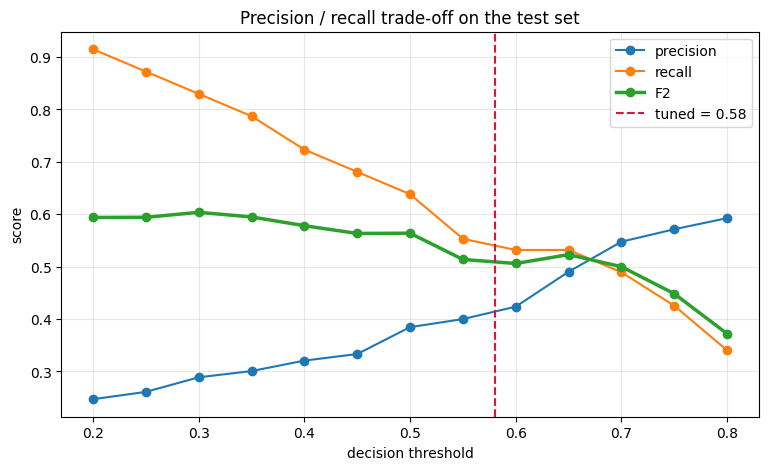

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep_df["threshold"], sweep_df["precision"], marker="o", label="precision")
ax.plot(sweep_df["threshold"], sweep_df["recall"], marker="o", label="recall")
ax.plot(sweep_df["threshold"], sweep_df["f2"], marker="o", label="F2", linewidth=2.5)
ax.axvline(threshold, color="crimson", linestyle="--", label=f"tuned = {threshold}")
ax.set_xlabel("decision threshold")
ax.set_ylabel("score")
ax.set_title("Precision / recall trade-off on the test set")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Performance at the tuned threshold

In [8]:
final = evaluate(y_test.to_numpy(), probabilities, threshold)
pd.Series(final).to_frame("value")

,value
roc_auc,0.8006
pr_auc,0.5429
precision,0.4262
recall,0.5532
f1,0.4815
f2,0.5221
threshold,0.5800


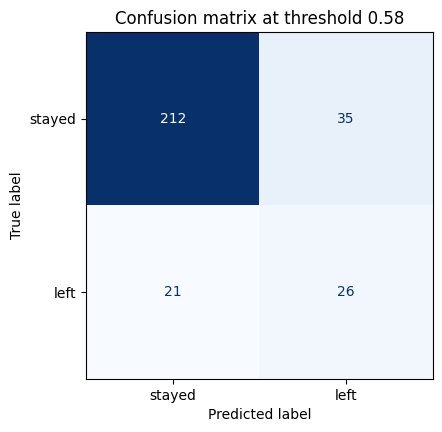

caught 26 of 47 actual leavers; missed 21
flagged 35 employees who in fact stayed


In [9]:
predictions = (probabilities >= threshold).astype(int)
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, predictions, display_labels=["stayed", "left"], cmap="Blues", ax=ax,
    colorbar=False)
ax.set_title(f"Confusion matrix at threshold {threshold}")
plt.show()

tn, fp, fn, tp = np.ravel(pd.crosstab(y_test, predictions).reindex(
    index=[0, 1], columns=[0, 1], fill_value=0).to_numpy())
print(f"caught {tp} of {tp + fn} actual leavers; missed {fn}")
print(f"flagged {fp} employees who in fact stayed")

## ROC and precision-recall curves

The PR curve is the more informative of the two on an imbalanced target, because it
ignores the large, easy true-negative population.

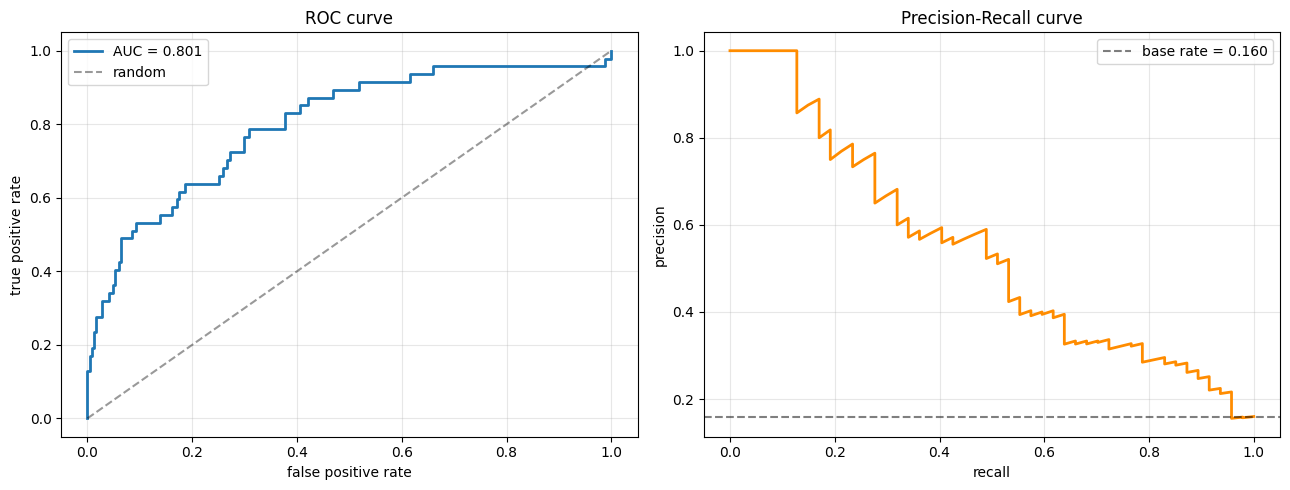

In [10]:
fpr, tpr, _ = roc_curve(y_test, probabilities)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, probabilities)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc_score(y_test, probabilities):.3f}")
ax1.plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")
ax1.set(xlabel="false positive rate", ylabel="true positive rate", title="ROC curve")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(recall_curve, precision_curve, linewidth=2, color="darkorange")
ax2.axhline(y_test.mean(), color="k", linestyle="--", alpha=0.5,
            label=f"base rate = {y_test.mean():.3f}")
ax2.set(xlabel="recall", ylabel="precision", title="Precision-Recall curve")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## What the linear model learned

Coefficients are directly readable, which is exactly why a linear baseline is worth
having before reaching for anything more complex.

In [11]:
feature_names = baseline.named_steps["preprocess"].get_feature_names_out()
coefficients = baseline.named_steps["model"].coef_[0]
coef_df = (pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
           .assign(magnitude=lambda d: d["coefficient"].abs())
           .sort_values("magnitude", ascending=False))

print("--- pushes attrition UP ---")
print(coef_df.nlargest(10, "coefficient")[["feature", "coefficient"]].to_string(index=False))
print("\n--- pushes attrition DOWN ---")
print(coef_df.nsmallest(10, "coefficient")[["feature", "coefficient"]].to_string(index=False))

--- pushes attrition UP ---
                         feature  coefficient
   JobRole_Laboratory Technician     1.124936
    JobRole_Sales Representative     1.032328
BusinessTravel_Travel_Frequently     0.857537
                    OverTime_Yes     0.826329
  EducationField_Human Resources     0.618911
         YearsSinceLastPromotion     0.600568
            MaritalStatus_Single     0.534138
         JobRole_Human Resources     0.526208
 EducationField_Technical Degree     0.419364
                   MonthlyIncome     0.387264

--- pushes attrition DOWN ---
                          feature  coefficient
        JobRole_Research Director    -1.553098
        BusinessTravel_Non-Travel    -1.005077
                      OverTime_No    -0.861715
               AvgYearsPerCompany    -0.686741
             EducationField_Other    -0.623072
                 ManagerStability    -0.534129
JobRole_Healthcare Representative    -0.511459
                  JobRole_Manager    -0.487818
           M

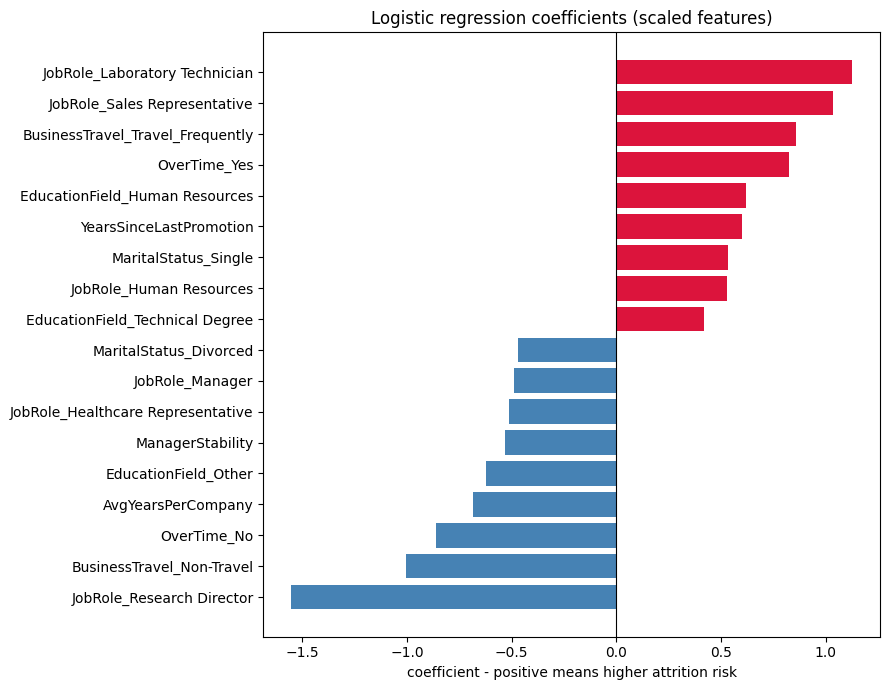

In [12]:
top = coef_df.head(18).sort_values("coefficient")
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top["feature"], top["coefficient"],
        color=["crimson" if c > 0 else "steelblue" for c in top["coefficient"]])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic regression coefficients (scaled features)")
ax.set_xlabel("coefficient - positive means higher attrition risk")
plt.tight_layout()
plt.show()

### Reading the coefficients

**Job role dominates.** `Laboratory Technician` and `Sales Representative` carry the
largest positive coefficients, and `Research Director` the largest negative one -
which lines up exactly with the raw attrition rates by role in notebook 01. The model
has not discovered anything exotic; it has confirmed the pattern already visible in
the data.

**Overtime is the strongest single behavioural driver.** It is split across two dummy
columns, `OverTime_Yes` (+0.83) and `OverTime_No` (-0.86), so its full effect is the
span between them - roughly 1.69, larger than any individual role coefficient. Reading
only the positive column would understate it. The same applies to business travel.

`YearsSinceLastPromotion` and `MaritalStatus_Single` push risk up; longer average
stints per company and manager stability push it down.

One coefficient deserves a caveat: `MonthlyIncome` appears with a *positive* sign,
which reads as "higher pay increases attrition risk" and is the opposite of what the
raw data shows. It is an artefact of collinearity - `JobLevel`, `IncomePerJobLevel`
and `IncomePerYearAtCompany` all encode pay, and the model distributes the effect
across them. Individual coefficients in a collinear linear model are not reliable
statements about isolated causes. That is precisely why notebook 08 uses SHAP, which
attributes contributions per prediction rather than per column.

The signals are coherent overall, so the baseline is behaving sensibly. Notebook 07
checks whether the more complex models beat it.